In [87]:
print("Welcome to TITANIC dataset:)")

Welcome to TITANIC dataset:)


In [88]:
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
train_data = pd.read_csv("train_titanic.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
train_data.shape

(891, 12)

In [91]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [92]:
train_data.columns.isnull().sum()

np.int64(0)

In [93]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [94]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [95]:
#Confision matrix kullanacağız ; Classsification kullanırız burada

In [96]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_data["Sex"]  = le.fit_transform(train_data["Sex"])
#MAN-> 1
#WOMAN->0
train_data["Sex"].unique()

array([1, 0])

In [97]:
man_died_count = len(train_data[(train_data["Sex"] == 1) & (train_data["Survived"] == 0)])
woman_died_count = len(train_data[(train_data["Sex"] == 0) & (train_data["Survived"] == 0)])

man_survived_count = len(train_data[(train_data["Sex"] == 1) & (train_data["Survived"] == 1)])
woman_survived_count = len(train_data[(train_data["Sex"] == 0) & (train_data["Survived"] == 1)])

man_percentage_survive = (man_survived_count / len(train_data[train_data["Sex"] == 1]))*100
woman_percentage_survive = (woman_survived_count / len(train_data[train_data["Sex"] == 0]))*100

print(f"{man_survived_count + woman_survived_count} people survived \n{man_survived_count} man \n{woman_survived_count} women")
print()
print(f"{man_died_count + woman_died_count} people died \n{man_died_count} man \n{woman_died_count} women")
print()
print(f"{man_percentage_survive:.3f}% man survived \n{woman_percentage_survive:.3f}% woman survived")

342 people survived 
109 man 
233 women

549 people died 
468 man 
81 women

18.891% man survived 
74.204% woman survived


In [98]:
train_data["Pclass"].unique()

array([3, 1, 2])

In [99]:
Pclass_1_mean_fare = train_data[train_data["Pclass"] == 1]["Fare"].mean()
Pclass_2_mean_fare = train_data[train_data["Pclass"] == 2]["Fare"].mean()
Pclass_3_mean_fare = train_data[train_data["Pclass"] == 3]["Fare"].mean()

print(f"Class 1 average ticket fare: {Pclass_1_mean_fare:.2f}$")
print(f"Class 2 average ticket fare: {Pclass_2_mean_fare:.2f}$")
print(f"Class 3 average ticket fare: {Pclass_3_mean_fare:.2f}$")

Class 1 average ticket fare: 84.15$
Class 2 average ticket fare: 20.66$
Class 3 average ticket fare: 13.68$


/var/folders/s3/kqmlr2qj7ld1gv4_m6hhb8700000gn/T/ipykernel_89992/845758739.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


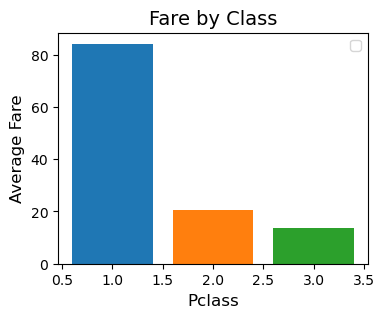

In [100]:
classes = [1, 2, 3]
fares = [Pclass_1_mean_fare, Pclass_2_mean_fare, Pclass_3_mean_fare]

plt.figure(figsize = (4,3))
plt.bar(classes, fares, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Fare by Class', fontsize=14)
plt.xlabel('Pclass', fontsize=12)
plt.ylabel('Average Fare', fontsize=12)

plt.legend()

In [101]:
'''
#   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  

 10  Cabin        204 non-null    object 

 bu columnlara bak!
'''

'\n#   Column       Non-Null Count  Dtype  \n---  ------       --------------  -----  \n\n 10  Cabin        204 non-null    object \n\n bu columnlara bak!\n'

In [102]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [103]:
train_data["Ticket"].nunique()
#number of unique

681

In [104]:
print(train_data["Age"].mean())
print(train_data["Age"].median())
print(train_data["Age"].mode())

29.69911764705882
28.0
0    24.0
Name: Age, dtype: float64


In [105]:
train_data["Age"] = train_data["Age"].fillna(train_data["Age"].median())
#Mean and Median was closely each other.

In [106]:
train_data["Age"].isnull().sum()

np.int64(0)

In [107]:
train_data["Ticket"].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [108]:
train_data["Cabin"]

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object

In [109]:
train_data = train_data.drop(columns=["Name", "PassengerId"], axis=1)

In [110]:
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,0,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,0,35.0,1,0,113803,53.1000,C123,S
4,0,3,1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,211536,13.0000,NaN,S
887,1,1,0,19.0,0,0,112053,30.0000,B42,S
888,0,3,0,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,1,26.0,0,0,111369,30.0000,C148,C


In [111]:
train_data['Ticket_Group_Size'] = train_data.groupby('Ticket')['Ticket'].transform('count')
train_data
#train_data['Ticket_Group_Size'] is result of future engineering it calculates how many same ticket are there.

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_Group_Size
0,0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,1,1,0,38.0,1,0,PC 17599,71.2833,C85,C,1
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,1,1,0,35.0,1,0,113803,53.1000,C123,S,2
4,0,3,1,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,211536,13.0000,NaN,S,1
887,1,1,0,19.0,0,0,112053,30.0000,B42,S,1
888,0,3,0,28.0,1,2,W./C. 6607,23.4500,NaN,S,2
889,1,1,1,26.0,0,0,111369,30.0000,C148,C,1


In [112]:
def extracting_begin_ticket_string(data):

    data = str(data).strip()

    if data.isdigit():
        return "Numeric"
    else:

        pairs = data.split()
        first_pair = pairs[0]
        cleaned_first_pair = first_pair.replace(".", "").replace("/", "").upper().strip()

        return cleaned_first_pair

train_data["Ticket_Prefix"] = train_data["Ticket"].apply(
    extracting_begin_ticket_string)


print(train_data["Ticket_Prefix"].unique())

['A5' 'PC' 'STONO2' 'Numeric' 'PP' 'CA' 'SCPARIS' 'SCA4' 'A4' 'SP' 'SOC'
 'WC' 'SOTONOQ' 'WEP' 'STONO' 'C' 'SOP' 'FA' 'LINE' 'FCC' 'SWPP' 'SCOW'
 'PPP' 'SC' 'SCAH' 'AS' 'SOPP' 'FC' 'SOTONO2' 'CASOTON']


In [115]:
# Target encoding

Ticket_percentage = train_data.groupby("Ticket_Prefix")["Survived"].mean()

train_data["Ticket_survival_percentage"] = train_data["Ticket_Prefix"].map(Ticket_percentage).round(3)

train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_Group_Size,Ticket_Prefix,Ticket_survival_percentage
0,0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,1,A5,0.095
1,1,1,0,38.0,1,0,PC 17599,71.2833,C85,C,1,PC,0.650
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,STONO2,0.500
3,1,1,0,35.0,1,0,113803,53.1000,C123,S,2,Numeric,0.384
4,0,3,1,35.0,0,0,373450,8.0500,NaN,S,1,Numeric,0.384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,211536,13.0000,NaN,S,1,Numeric,0.384
887,1,1,0,19.0,0,0,112053,30.0000,B42,S,1,Numeric,0.384
888,0,3,0,28.0,1,2,W./C. 6607,23.4500,NaN,S,2,WC,0.100
889,1,1,1,26.0,0,0,111369,30.0000,C148,C,1,Numeric,0.384


In [118]:
train_data = train_data.drop(["Ticket"], axis=1)
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Ticket_Group_Size,Ticket_Prefix,Ticket_survival_percentage
0,0,3,1,22.0,1,0,7.2500,NaN,S,1,A5,0.095
1,1,1,0,38.0,1,0,71.2833,C85,C,1,PC,0.650
2,1,3,0,26.0,0,0,7.9250,NaN,S,1,STONO2,0.500
3,1,1,0,35.0,1,0,53.1000,C123,S,2,Numeric,0.384
4,0,3,1,35.0,0,0,8.0500,NaN,S,1,Numeric,0.384
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,NaN,S,1,Numeric,0.384
887,1,1,0,19.0,0,0,30.0000,B42,S,1,Numeric,0.384
888,0,3,0,28.0,1,2,23.4500,NaN,S,2,WC,0.100
889,1,1,1,26.0,0,0,30.0000,C148,C,1,Numeric,0.384


In [119]:
train_data = train_data.drop(["Ticket_Prefix"], axis=1)
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Ticket_Group_Size,Ticket_survival_percentage
0,0,3,1,22.0,1,0,7.2500,NaN,S,1,0.095
1,1,1,0,38.0,1,0,71.2833,C85,C,1,0.650
2,1,3,0,26.0,0,0,7.9250,NaN,S,1,0.500
3,1,1,0,35.0,1,0,53.1000,C123,S,2,0.384
4,0,3,1,35.0,0,0,8.0500,NaN,S,1,0.384
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,NaN,S,1,0.384
887,1,1,0,19.0,0,0,30.0000,B42,S,1,0.384
888,0,3,0,28.0,1,2,23.4500,NaN,S,2,0.100
889,1,1,1,26.0,0,0,30.0000,C148,C,1,0.384


In [120]:
train_data["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [121]:
train_data["Cabin"].isnull().sum()

np.int64(687)